## Brownian Motion

Taken from Dialid's workshop notes

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import seaborn as sns 
sns.set(style="whitegrid")

%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

## Definition

**Definition** A standard Brownian motion or Weiner process is a stochastic process $W =\{W_t, t\geq 0\}$ characterised by the following properties:
1. $W_0 = 0$
2. $W_t-W_s \sim N(0, t-s),$ for any $0\leq s \leq t$
3. $W_t$ has independent increments
4. $W_t$ is almost surely continuous.

The definition implies that  each marginal distribution $W_t$ is normally distributed with $E[W_t] = 0$, and $Var[W_t]=t$. So, we can simulate it by using *norm* from *scipy* wih location and scale parameters 0 and t, respectively.

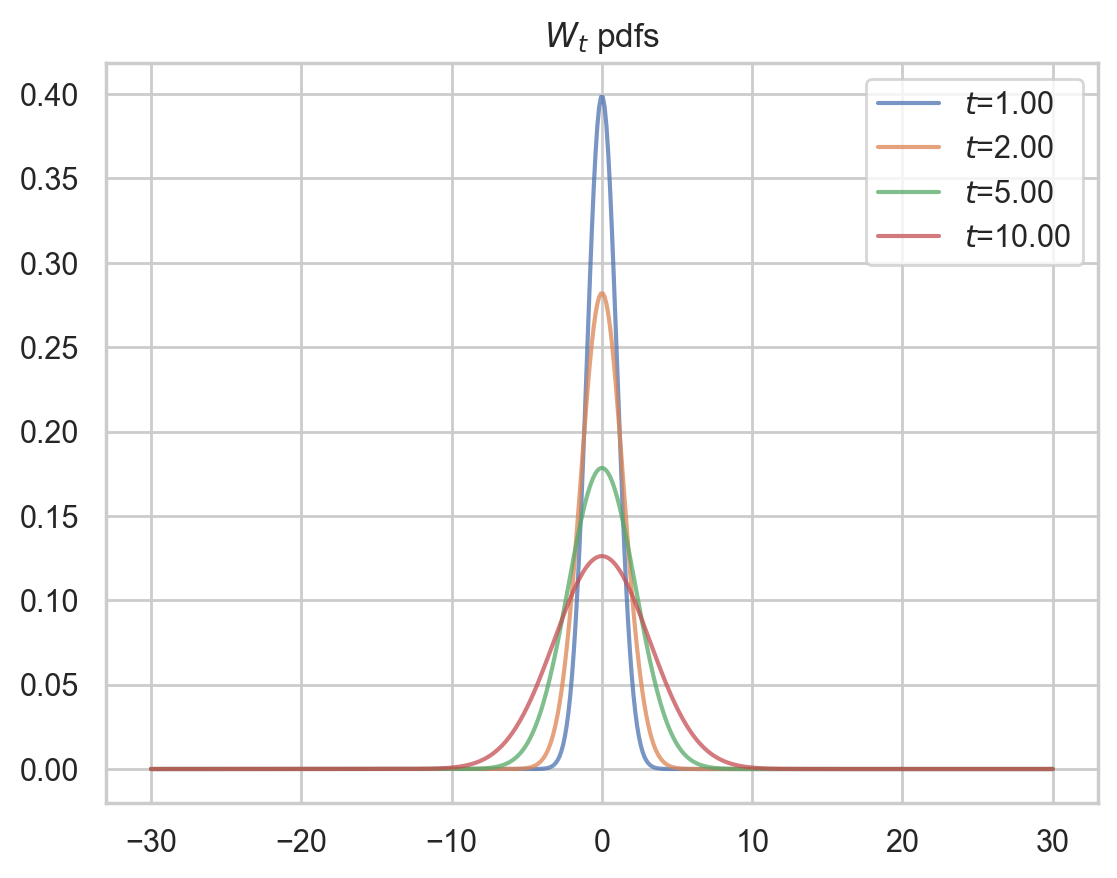

In [7]:
from scipy.stats import norm

fig, ax1 = plt.subplots(1, 1)
for t in [1,2,5, 10]:
    Wt_variable = norm(loc=0, scale= np.sqrt(t))
    x = np.linspace(-30, 30, 500)
    ax1.plot(x, Wt_variable.pdf(x), '-', lw=1.5,
             alpha=0.75, label=f'$t$={t:.2f}')
ax1.legend()
plt.title('$W_t$ pdfs')
plt.show()

### Brownian Motion Simulation

In [10]:
def get_times(t0=0.0, T=1.0, steps=30):

    dt = (T-t0)/steps
    times = np.arange(t0, T+dt, dt)
    return times

In [33]:
# np.random.seed(123)  # Fix the seed for reproducibility
ts = get_times(t0=0, T=10, steps=200)
n = len(ts)
dt = (ts[n-1] - ts[0])/n
increments = norm.rvs(loc=0, scale=np.sqrt(dt), size=n-1)
increments = np.insert(increments, 0, 0) # Adding the initial point W_0 = 0
ws = increments.cumsum()

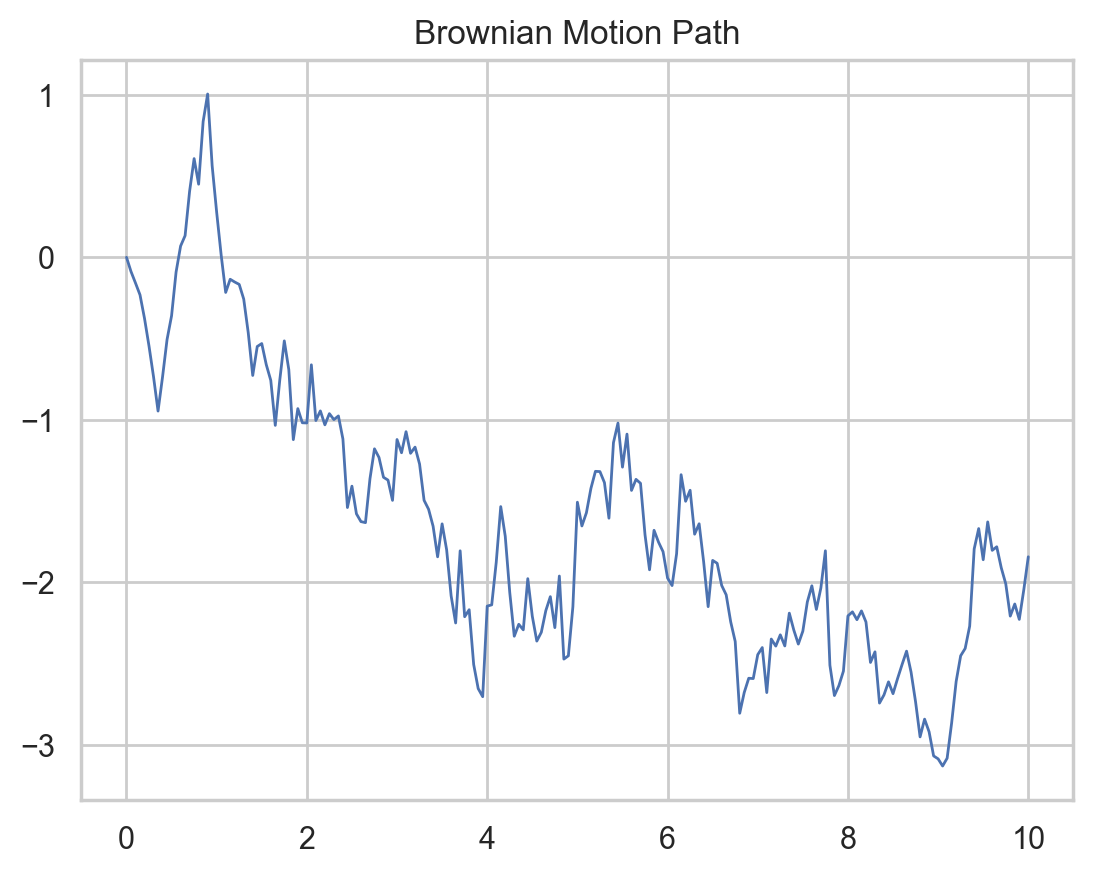

In [34]:
plt.plot(ts, ws, '-', lw=1)
plt.title('Brownian Motion Path')
plt.show()

Let's make a function which returns a brownian path for a given grid of times:

In [18]:
def get_brownian_path(ts, bt0=0.0):

    n = len(ts)
    dt = (ts[n-1] - ts[0])/n
    increments = norm.rvs(loc=0, scale=np.sqrt(dt), size=n-1)
    increments = np.insert(increments, 0, bt0)
    bs = increments.cumsum()

    return bs

Now we can plot several paths:

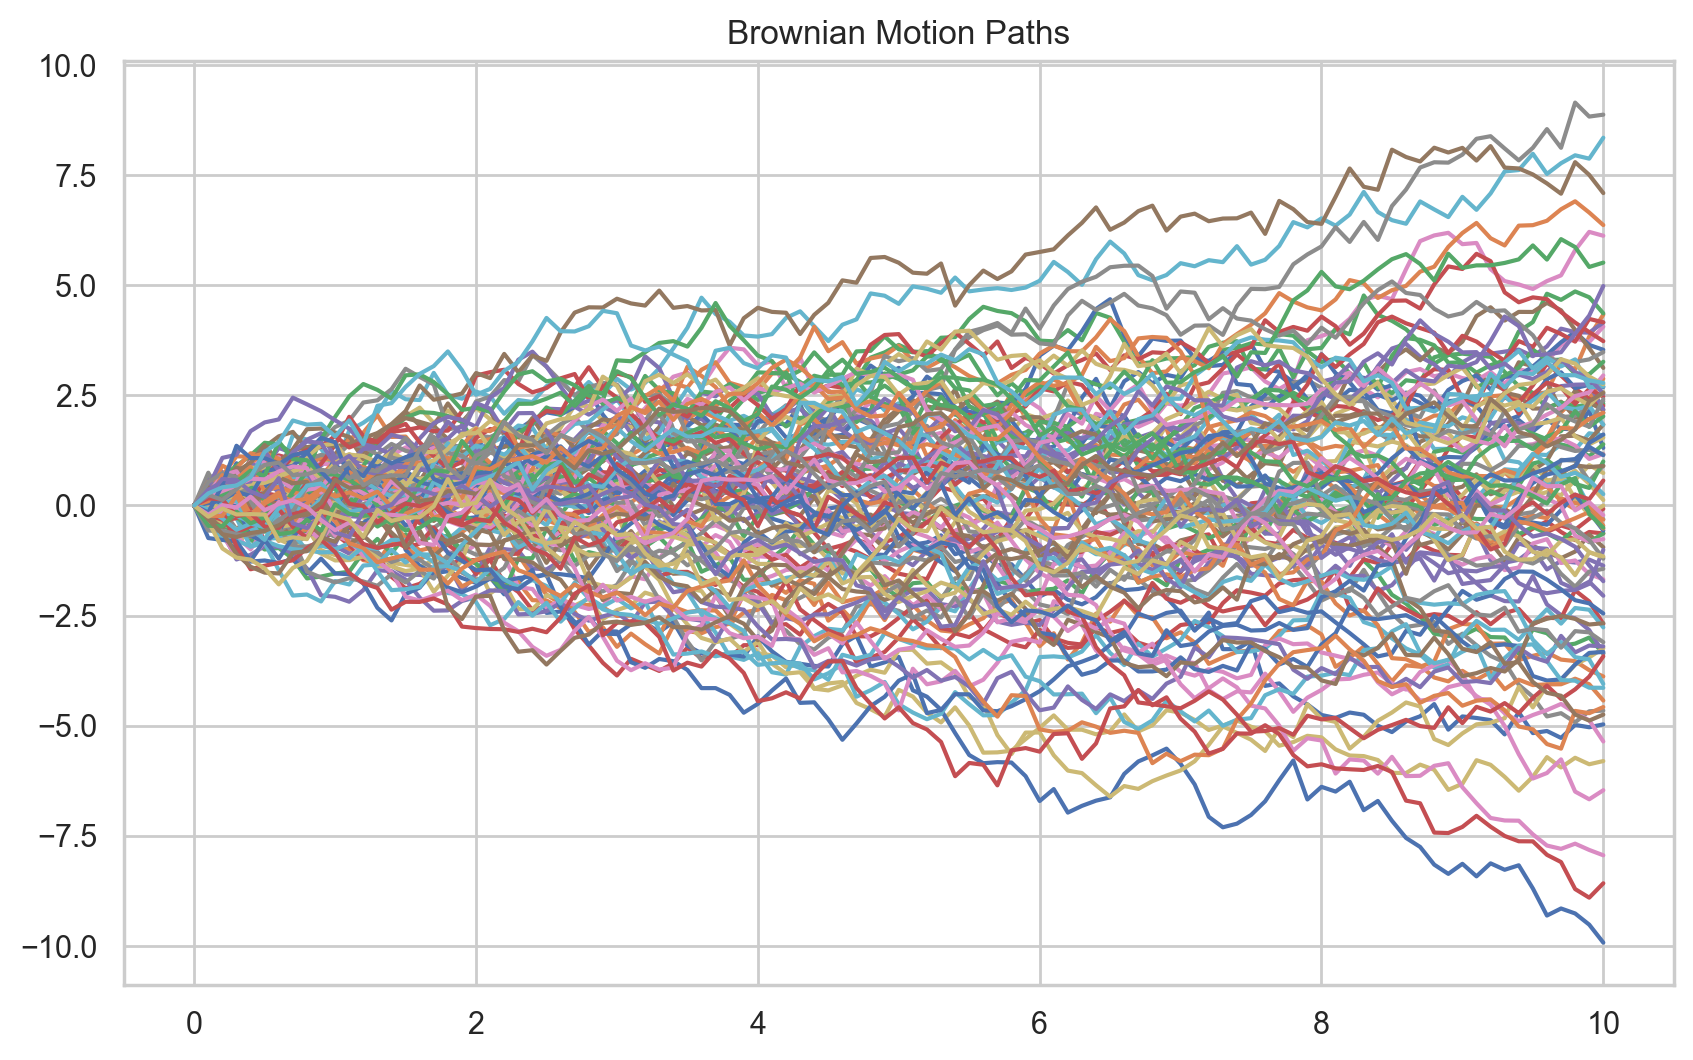

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
ts = get_times(T=10, steps=100)
for m in range(100):
    bms = get_brownian_path(ts)
    ax.plot(ts, bms, '-', lw=1.5)
plt.title('Brownian Motion Paths')
plt.show()


## Geometric Brownian Motion

In [35]:
from scipy.stats import lognorm

## Definition

Geometric Brownian motion is defined by the following Stochastic Differential Equation (SDE)
\begin{align}
dS_t &= \mu S_t dt + \sigma S_t W_t, \quad t >0,\\
\end{align}
where $S_0 =s_0>0$, and $W_t$ is a standard Brownian motion. In order to find its solution, let us set $X_t = \log(S_t)$. Using Ito's formula, we obtain

$$X_t = X_0 +  \left( \mu-\frac{1}{2}\sigma^2 \right)t  + \sigma W_t,$$

or equivalently 

$$\log(S_t) = \log(s_0) +  \left( \mu-\frac{1}{2}\sigma^2 \right)t  + \sigma W_t.$$

Note that the last expression implies that $\log(S_t)$ follows a normal distribution $\mathcal{N}\left(\log(s_0) +  \left( \mu-\frac{1}{2}\sigma^2 \right)t, \sigma^2 t\right )$. This implies that 

$$S_t = s_0 \exp\left\{ \left( \mu-\frac{1}{2}\sigma^2 \right)t  + \sigma W_t   \right\}, \quad \forall t>0,$$

follows a log-normal distribution.

Let's take a look at the density function of $S_1$ for different values of $\mu$ and $\sigma$. To do this we will write a function which returns a marginal distribution of the process, i.e. a random variable $S_t$.

In [36]:
def gb_rv(s0, mu, sigma, t):

    mu_x = np.log(s0) + (mu - 0.5*sigma**2)*t
    sigma_x = sigma*np.sqrt(t)
    gb_variable = lognorm(s=sigma_x, scale=np.exp(mu_x))

    return gb_variable

Now, we can plot $S_1$ for different values of $\mu$ and $\sigma$. 

First, we fix $\sigma$ and vary $\mu$.

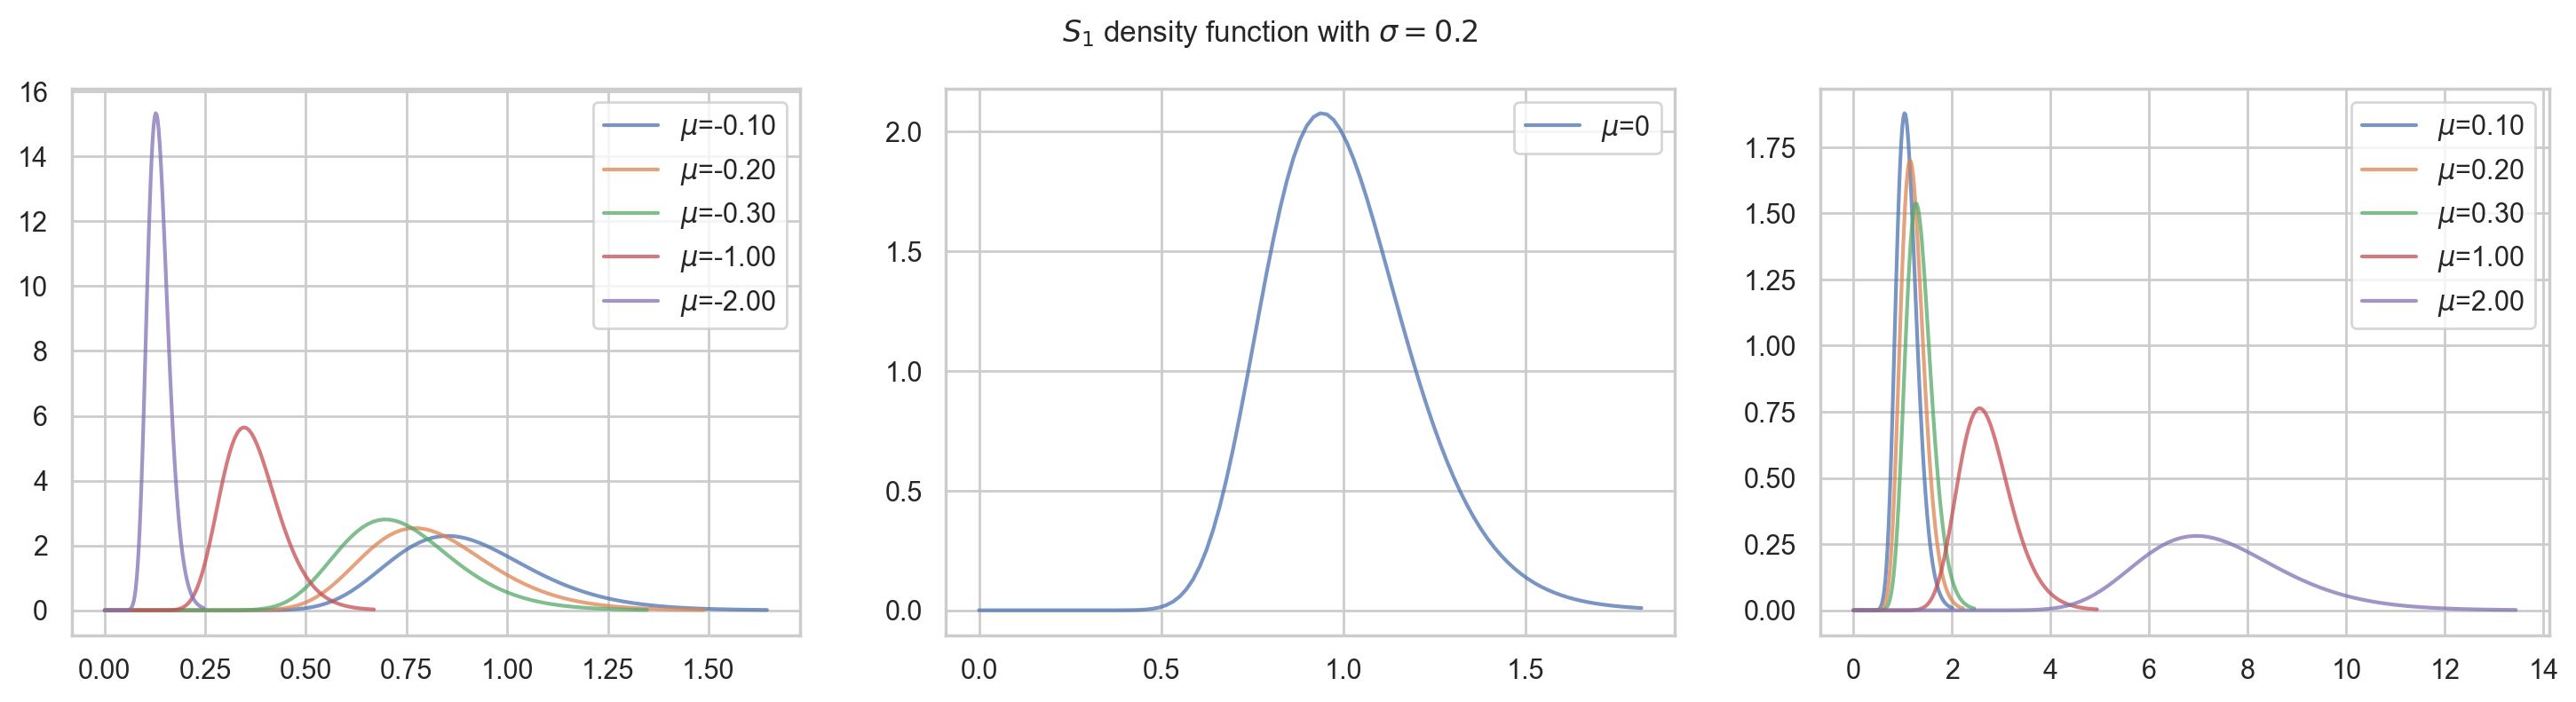

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
for mu in [-0.1, -0.2, -0.3, -1, -2]:
    St_variable = gb_rv(s0=1.0, mu=mu, sigma=0.2, t=1)
    x = np.linspace(0, St_variable.ppf(0.999), 100)
    ax1.plot(x, St_variable.pdf(x), '-', lw=1.5, alpha=0.75, label=f'$\mu$={mu:.2f}')
ax1.legend()
for mu in [0]:
    St_variable = gb_rv(s0=1.0, mu=mu, sigma=0.2, t=1)
    x = np.linspace(0, St_variable.ppf(0.999), 100)
    ax2.plot(x, St_variable.pdf(x), '-', lw=1.5,
             alpha=0.75, label=f'$\mu$={mu}')
ax2.legend()

for mu in [0.1, 0.2, 0.3, 1, 2]:
    St_variable = gb_rv(s0=1.0, mu=mu, sigma=0.2, t=1)
    x = np.linspace(0, St_variable.ppf(0.999), 100)
    ax3.plot(x, St_variable.pdf(x), '-', lw=1.5,
             alpha=0.75, label=f'$\mu$={mu:.2f}')
ax3.legend()
fig.suptitle('$S_1$ density function with $\sigma=0.2$', size=12)
plt.show()

### Expectation and Variance

To calculate the expectation of $S_t$, we are going to use the fact that the process $M_t = \exp \{ \sigma W_t - \dfrac{1}{2}\sigma^2 t\}$ is an exponential martingale. Then
\begin{align*}
E\left[S_t \right] &= E\left[s_0\exp \left\{ (\mu  - \dfrac{1}{2}\sigma^2) t +   \sigma W_t \right\} \right]\\
&= s_0\exp \left\{ \mu t   \right\}  E\left[\exp \left\{  - \dfrac{1}{2}\sigma^2 t +  \sigma W_t \right\} \right]\\
&=s_0\exp \left\{ \mu t   \right\}.
\end{align*}

Similarly, for the variance we will use the fact that the process $M_t = \exp \left\{ 2\sigma W_t - 2\sigma^2 t \right\}$ is an exponential martingale. Then
\begin{align*}
E\left[S_t^2 \right]
&=E\left[s_0^2\exp \left\{  2\mu t- \sigma^2 t  +2\sigma W_t  \right\} \right] \\
&=s_0^2\exp \left\{2\mu t + \sigma^2 t  \right\}  E\left[s_0^2\exp \left\{ 2\sigma W_t - 2\sigma^2 t \right\} \right] \\
& =s_0^2 \exp \left\{(2\mu + \sigma^2 ) t \right\}.
\end{align*}
Hence
\begin{align*}
Var[ S_t] &= E\left[S_t^2 \right] - E\left[S_t \right]^2\\
& =s_0^2\exp \left\{(2\mu + \sigma^2 ) t \right\} - s_0^2\exp \left\{2\mu t \right\}\\
& = s_0^2\exp \left\{2\mu t \right\} \left(\exp \left\{\sigma^2 t \right\} - 1\right).
\end{align*}
So, for given $s_0, \mu, \sigma,$ and $t$, we can calculate both the expectation and the variance of $S_t$ using these formulas.

In [38]:
s0 = 1.0
mu = 0.1
sigma = 0.2
t= 10
print(f'For s_0={s0}' , f'mu={mu}', f'sigma=.{sigma}', f't={t}', sep=", ")
print(f'E[S_t]={(s0*np.exp(mu*t)):.2f}', f'Var[S_t]={(s0**2)*np.exp(2*mu*t)*(np.exp(t*sigma**2)-1) :.2f}', sep="\n")

For s_0=1.0, mu=0.1, sigma=.0.2, t=10
E[S_t]=2.72
Var[S_t]=3.63


In [39]:
mu_x = np.log(s0) + (mu - 0.5*sigma**2)*t
sigma_x = sigma*np.sqrt(t)
St_variable = lognorm(s=sigma_x, scale=np.exp(mu_x))
print(
      f'E[S_t]={St_variable.mean():.2f}',
      f'Var[S_t]={St_variable.var():.2f}', sep="\n")

E[S_t]=2.72
Var[S_t]=3.63


### Simulation

In [40]:
def get_times(t0=0.0, T=1.0, steps=30):

    dt = (T-t0)/steps
    times = np.arange(t0, T+dt, dt)
    return times

def get_brownian_path(ts, bt0=0):

    n = len(ts)
    dt = (ts[n-1] - ts[0])/n
    increments = norm.rvs(loc=0, scale=np.sqrt(dt), size=n-1)
    increments = np.insert(increments, 0, bt0)
    bs = increments.cumsum()

    return bs

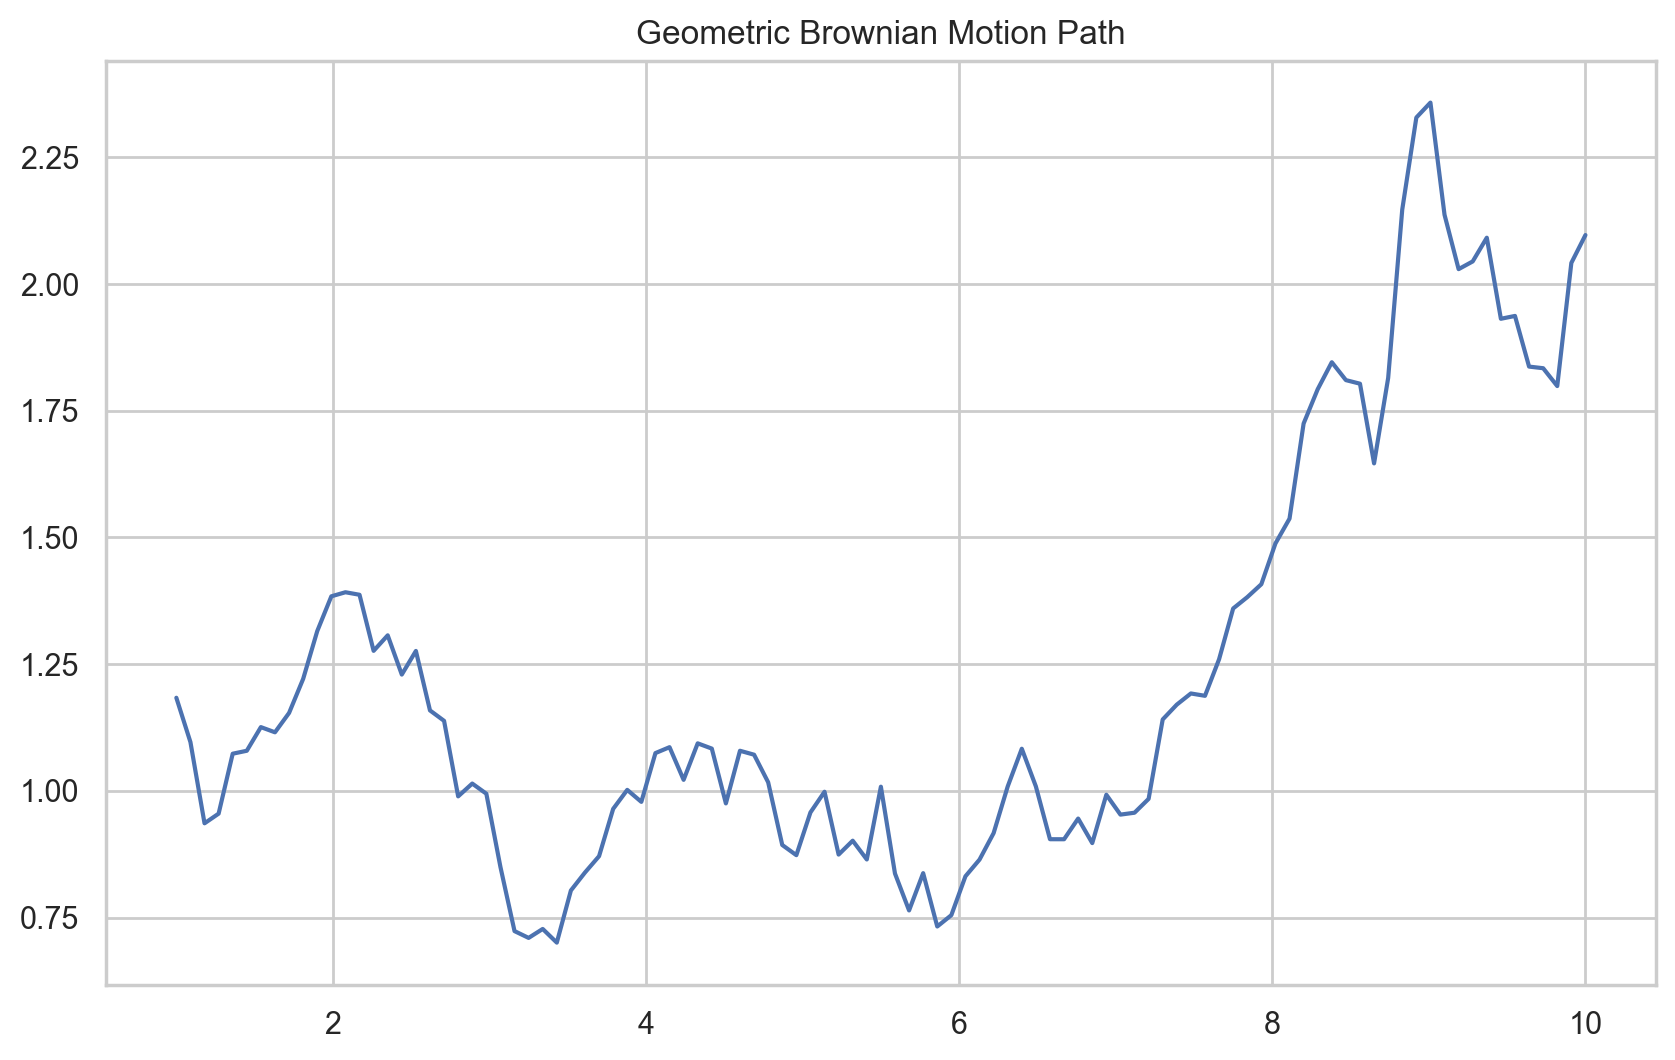

In [41]:
ts = get_times(t0=1, T=10, steps=100)
ws = get_brownian_path(ts)

s0 = 1
mu = 0.2
sigma = 0.25

gbs = s0*np.exp((mu-0.5*sigma**2)*ts + sigma*ws)
plt.figure(figsize=(10,6))
plt.plot(ts, gbs, '-', lw=1.5, label='GBM')
plt.title('Geometric Brownian Motion Path')
plt.show()

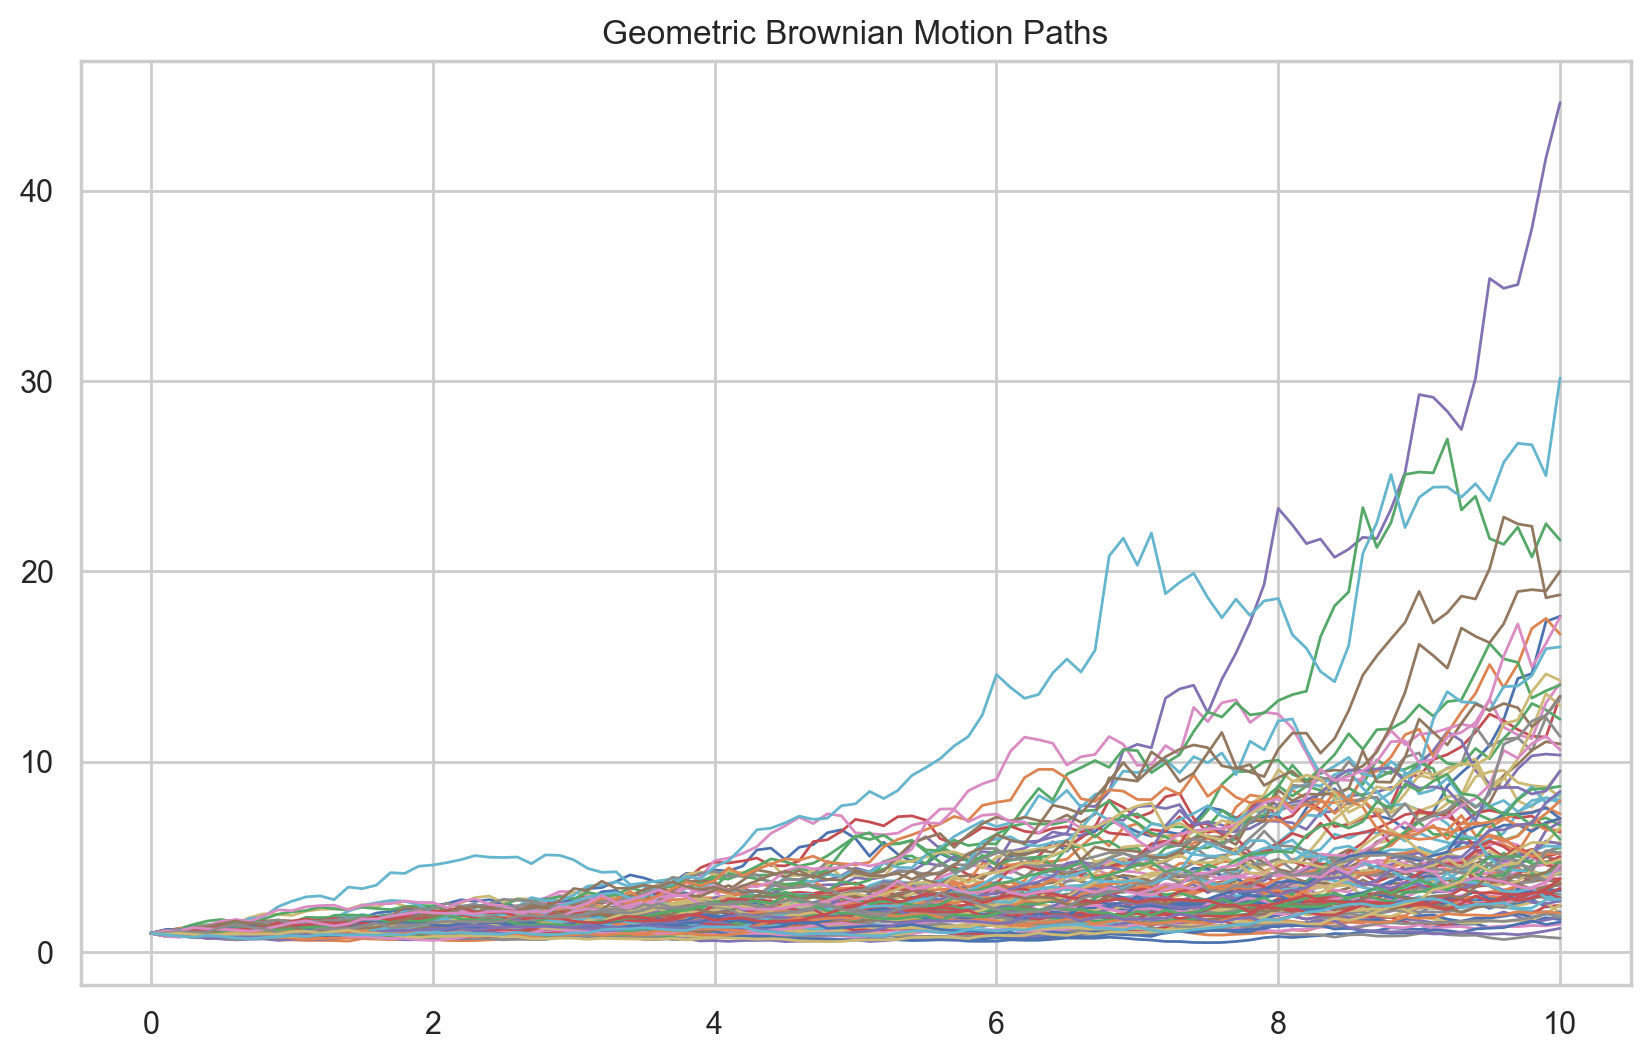

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
ts = get_times(T=10, steps=100)


for m in range(100):
    ws = get_brownian_path(ts)
    gbs = s0*np.exp((mu-0.5*sigma**2)*ts + sigma*ws)
    ax.plot(ts, gbs, '-', lw=1)
plt.title('Geometric Brownian Motion Paths')
plt.show()

## Black-Scholes Model

For equity derivatives without dividends.


## European Option

An option is a contract which conveys to its owner, the holder, the right, but not the obligation, to buy (Call) or sell (Put) an underlying asset or instrument at a specified strike price $K$ on or before a specified expiry date $T$, depending on the style of the option. 




The key difference between American and European options relates to when the options can be exercised:

- A European option may be exercised only at the expiration date of the option $T$.
- An American option on the other hand may be exercised at any time before the expiration date.

For European options, the payoff—when it occurs—is given by

$$Call \ \ Payoff = (S_T - K)^{+}$$

$$Put \ \  Payoff = (K - S_T)^{+},$$

where $K$ is the strike price and $S_T$ is the price of the underlying asset at the time of exercise.

Consider an European option with strike given by $K$. Then, its payoff as a function of the the underlying price at the expiry $S_T$ is illustrated by the following function.

In [50]:
def draw_payoff(K):

    S = K
    underlying_prices = np.linspace(.0,  2*S, 100)
    values_call = [np.maximum(s - K, 0) for s in underlying_prices]
    values_put = [np.maximum(K-s, 0) for s in underlying_prices]

    plt.figure()
    plt.plot(underlying_prices, values_call, lw=1.,
             color="maroon", label="European Call")
    plt.plot(underlying_prices, values_put, lw=1.,
             color="cornflowerblue", label="European Put")
    plt.xlabel('$S_T$')
    plt.ylabel('Payoff')
    plt.title(f'European Option with strike $K$={K}')
    plt.legend()
    plt.show()

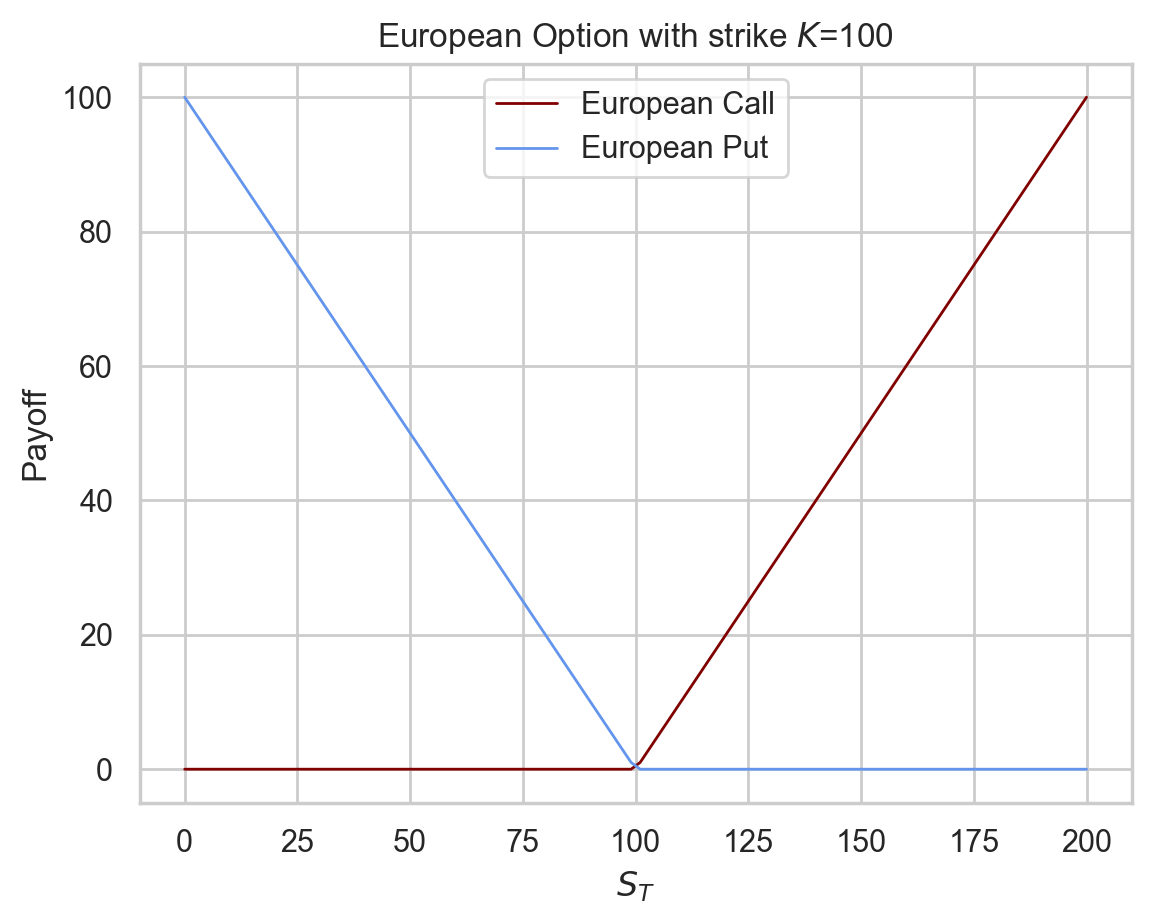

In [45]:
draw_payoff(K=100)

### Black-Scholes Model Assumptions

#### Assumptions

- (A1) The risk-free interest rate $r$ is known and constant through time
- (A2) The underlying asset/stock price $S$ follows a Geometric Brownian motion with constant parameters $\mu$ and $\sigma$, under a certain probability measure $\mathbb{P}$
- (A3) Stock pays no dividends
- (A4) The option can only be exercised at expiration i.e. it is a European type
- (A5) There are no transaction costs
- (A6) Fractional trading is possible


### Black-Scholes Equation Derivation
To derive the famous equation, the idea is to construct a self-financing portfolio with one option and $\Delta$ units of the underlying stock. So, the value of the portfolio at a given time $t$ is given by
$$\Pi_t = V_t + \Delta S_t,$$
and must satisfy the following two conditions:
- (C1) The portfolio is riskless
- (C2) The portfolio earns the risk free rate

Using assumption (A2)
$$dS_t = \mu S_t dt + \sigma S_t dW_t^{\mathbb{P}},$$
and Ito's formula applied to the function $V(t, S)$, we obtain
\begin{align*}
d \Pi_t &= dV_t + \Delta dS_t\\
&= \left[ \frac{\partial V}{\partial t} + \frac{\partial V}{\partial S} \mu S  + \frac{1}{2}\frac{\partial^2 V}{\partial S^2} \sigma^2 S^2 \right] dt +  \frac{\partial V}{\partial S} \sigma SdW_t^{\mathbb{P}} +    \Delta  dS_t\\
&= \left[ \frac{\partial V}{\partial t} + \frac{\partial V}{\partial S} \mu S  + \frac{1}{2}\frac{\partial^2 V}{\partial S^2} \sigma^2 S^2 \right] dt +  \frac{\partial V}{\partial S} \sigma SdW_t^{\mathbb{P}} +    \Delta  \mu S dt + \Delta \sigma SdW_t^{\mathbb{P}}\\
&= \left[ \frac{\partial V}{\partial t} + \frac{\partial V}{\partial S} \mu S  + \frac{1}{2}\frac{\partial^2 V}{\partial S^2} \sigma^2 S^2 +  \Delta  \mu S \right] dt +  \left[ \frac{\partial V}{\partial S} \sigma S +  \Delta \sigma S \right] dW_t^{\mathbb{P}}\\
&= \left[ \frac{\partial V}{\partial t} + \frac{\partial V}{\partial S} \mu S  + \frac{1}{2}\frac{\partial^2 V}{\partial S^2} \sigma^2 S^2  + \Delta  \mu S \right] dt +  \left[ \frac{\partial V}{\partial S}  +  \Delta \right] \sigma S dW_t^{\mathbb{P}}.\\
\end{align*}


Condition (C1) implies that the second term in the last expression should be equal zero. 

Thus, taking $\Delta = -\frac{\partial V}{\partial S}$ we obtain

\begin{align*}
d\Pi_t &= \left[ \frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2} \sigma^2 S^2 \right] dt.
\end{align*}

On the other hand, condition (C2) implies
\begin{align*}
d\Pi_t &= r \Pi_t dt = r \left[  V_t -\frac{\partial V}{\partial S} S_t \right].
\end{align*}

Combining the last two equations we obtain

\begin{align*}
\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2} \sigma^2 S^2  = r\left[  V_t -\frac{\partial V}{\partial S} S_t \right]dt,
\end{align*}

from which we can derive the following partial differential equation (PDE)

\begin{align*}
\frac{\partial V}{\partial t} + \frac{1}{2} \sigma^2 S^2  \frac{\partial^2 V}{\partial S^2} + r S_t\frac{\partial V}{\partial S}     - r  V_t  = 0 .
\end{align*}

Adding the final condition, which comes from (A4), we obtain the famous second order parabollic partial differential equation with boundary condition
\begin{align*}
\frac{\partial V}{\partial t}  + r^d S_t\frac{\partial V}{\partial S} + \frac{1}{2} \sigma^2 S^2  \frac{\partial^2 V}{\partial S^2}    - r V_t  &= 0, \qquad \qquad t \in [0,T]\\
V_T =  (S_T - &  K)^{+} .
\end{align*}

### Solution

The solution to this PDE with boundary condition is given by
\begin{align*}
V(S_t, t) = \Phi(d_1) S_t - \Phi(d_2)K e^{-r(T-t)},
\end{align*}
where
\begin{align*}
d_1 & = \dfrac{1}{\sigma \sqrt{T-t}} \left[ \ln \left(\frac{S_t}{K} \right) + \left( r + \dfrac{\sigma^2}{2}\right) (T-t)  \right]\\
d_2 & = d_1 - \sigma\sqrt{T-t},
\end{align*}
and $\Phi$ denotes the cumulative distribution function (cdf) of a standard normal distribution.

### Put-Call Parity

In financial mathematics, put–call parity defines a relationship between the price of a European call option and European put option, both with the identical strike price and expiry, namely that a portfolio of a long call option and a short put option is equivalent to (and hence has the same value as) a single forward contract at this strike price and expiry. This is because if the price at expiry is above the strike price, the call will be exercised, while if it is below, the put will be exercised, and thus in either case one unit of the asset will be purchased for the strike price, exactly as in a forward contract.


$$Call - Put = S - Ke^{-r(T-t)}.$$

In [58]:
from scipy.stats import norm

def BS_formula(payoff="call", S=100., K=100., tau=1., r=0.1, sigma=0.2):
    # Here tau = T-t Time to expiration
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*(tau))/(sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    
    if payoff == "call":
        price = norm.cdf(d1)*S - norm.cdf(d2)*K*np.exp(-r*tau)
    elif payoff=="put":
        price = -norm.cdf(-d1)*S + norm.cdf(-d2)*K*np.exp(-r*tau)
    else:
        raise ValueError("Payoff not implemented. Set 'call' or 'put'")

    return price

In [60]:
S=100.0     # St spot stock price
K=100.0     # strike
tau=1.0     # T-t
r=0.1       # risk free rate 
sigma=0.2   # diffusion coefficient or volatility

call = BS_formula("call", S, K, tau, r, sigma)
put = BS_formula("put", S, K, tau, r, sigma)

print(f'Call Price {call}')
print(f'Put price {put}')

Call Price 13.269676584660886
Put price 3.753418388256833


In [61]:
assert( call - put == S - K*np.exp(-r*tau) )

## Monte Carlo Intro

Example: Approximating the price of an European option

Monte Carlo methods can be thought of as a stochastic way to approximate integrals which can be written as expectations, i.e. 

$$\theta = \mathbb{E}[\phi (X)] 	\int_{\mathbb{R}^d} \phi(x) f_X(x)dx$$

where $\phi$ is a real function and $f_X$ represents the probability density function of a random variable $X$.

**Algorithm**

1. Simulate  $X_1, \cdots, X_n$  independent samples from a random variable with probability density function $f_X$
2. Return   $ \hat{\theta} _n= \frac{1}{n}\sum_{i=1}^{n} \phi(X_i)$.

### Estimate the Price of a European Option unde the B-S model

The idea is to use the fact the price of the option can be written as
$$  V(t,S_t) = e^{-r(T-t)} \mathbb{E}_t[(S_T - K)^+],$$

and that $S_T|S_t$ follows a log-normal distribution

$$S_T |S_t \sim LogNormal\left(\ln(S_t) +  \left( r-\frac{1}{2}\sigma^2 \right)(T-t),\sigma^2(T-t)\right),$$
or equivalently $\ln(S_T)|S_t$  follows a normal distribution

$$\ln(S_T) |S_t \sim \mathcal{N}\left( \ln(S_t) +  \left( r-\frac{1}{2}\sigma^2 \right)(T-t),\sigma^2(T-t) \right).$$ 

So, we simply generate independent samples $\{S_i\}_{i=1}^n$ from the log-normal distribution and then calculate the average

$$ \theta_n = e^{-r(T-t)}  \frac{1}{n} \sum_{i = 1}^n (S_i - K)^{+} $$

In [62]:
S=100.0     # St spot stock price
K=100.0     # strike
tau=1.0     # T-t
r=0.1       # risk free rate 
sigma=0.2   # diffusion coefficient or volatility
n=1000      # Number of simulations

Zs = norm.rvs(loc=0, scale=1, size=n)
Ss = S*np.exp((r - 0.5*sigma**2)*tau + sigma*np.sqrt(tau)*Zs)
Vs = np.exp(-r*tau)*np.maximum(Ss-K, 0)

mc_estimator = np.mean(Vs)

print(mc_estimator)

13.701223287073786


In [63]:
def BS_MonteCarlo(payoff="call", S=100., K=100., tau=1.0, r=0.1, sigma=0.2, n=1000):

    Zs = norm.rvs(loc=0, scale=1, size=n)
    Ss = S*np.exp((r - 0.5*sigma**2)*tau + sigma*np.sqrt(tau)*Zs)
    
    if payoff == "call":
        Vs = np.exp(-r*tau)*np.maximum(Ss-K, 0)
    elif payoff == "put":
        Vs = np.exp(-r*tau)*np.maximum(K-Ss, 0)
    else:
        raise ValueError("Payoff not implemented. Set 'call' or 'put'")

    mc_estimator = np.mean(Vs)

    return mc_estimator

In [64]:
BS_MonteCarlo(n=100)

15.865948492564193

In [65]:
BS_MonteCarlo(n=5000)

13.159574785939697

In [67]:
BS_formula()

13.269676584660886

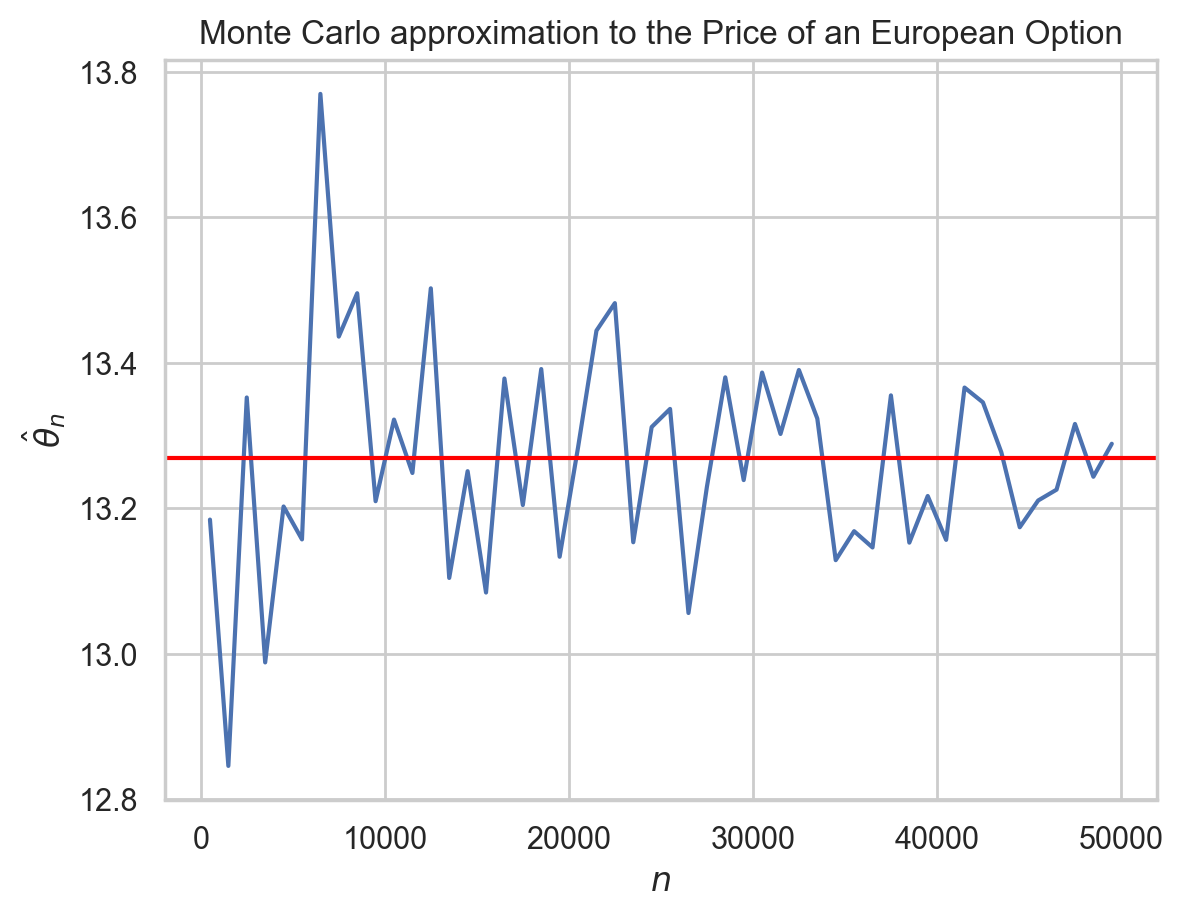

In [69]:
ns = np.arange(500, 50000, 1000)
estimates = [BS_MonteCarlo(n=n) for n in ns]
true_value = BS_formula()
plt.plot(ns, estimates)
plt.axhline(y = true_value, color='red', label='True Value')
plt.title('Monte Carlo approximation to the Price of an European Option')
plt.xlabel('$n$')
plt.ylabel(r'${\hat{\theta}}_n $')
plt.show()

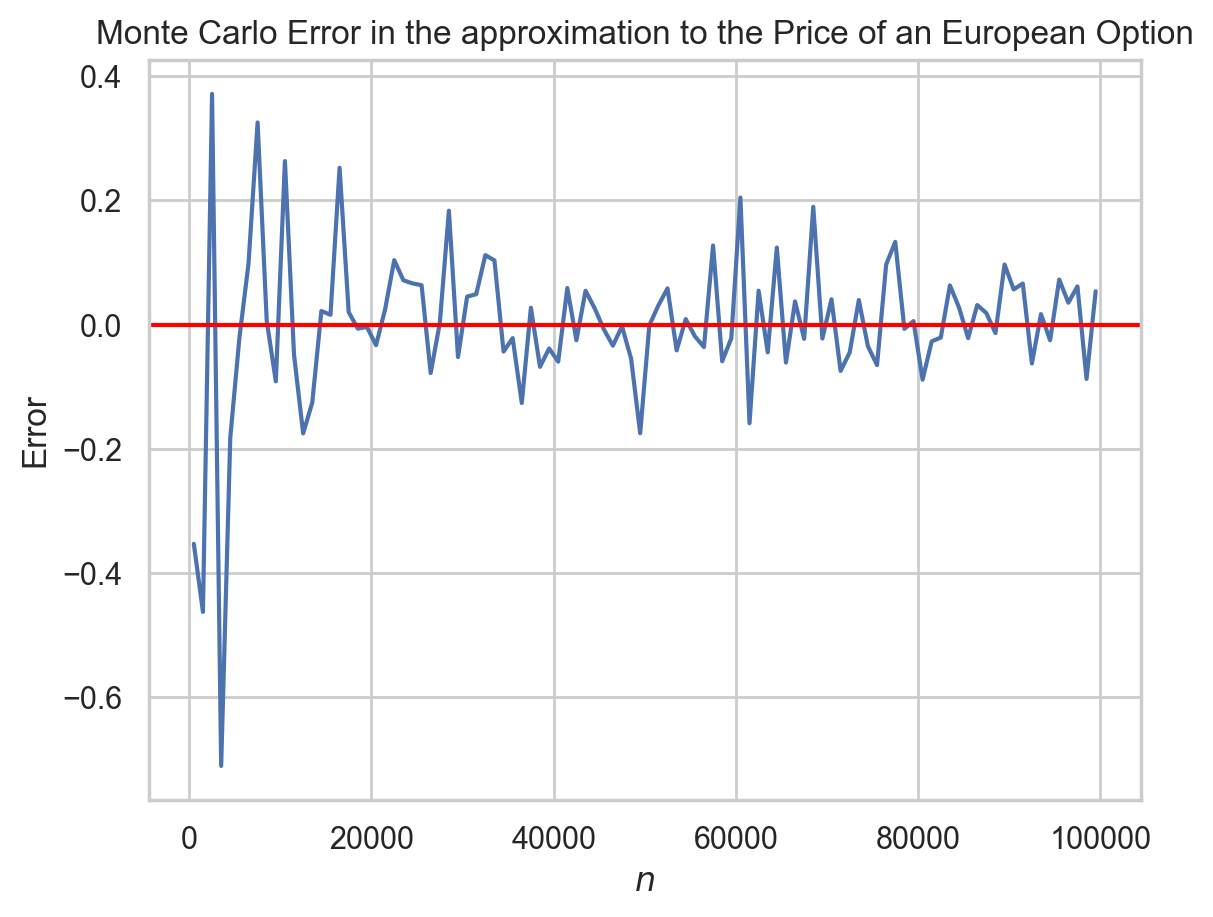

In [70]:
ns = np.arange(500, 100000, 1000)
errors = [BS_MonteCarlo(n=n) - true_value for n in ns]
plt.plot(ns, errors)
plt.axhline(y = 0.0, color='red')
plt.title('Monte Carlo Error in the approximation to the Price of an European Option')
plt.xlabel('$n$')
plt.ylabel(r'Error')
plt.show()